## 🔧 주요 설정 항목들

이 섹션에서는 PDF 문서 처리를 위한 핵심 설정들을 정의합니다.

### 📋 설정 항목 설명
- **IMAGE_RESOLUTION_SCALE**: 이미지 해상도 배율 (2.0 = 2배 해상도)
  - 높은 해상도는 더 선명한 이미지를 제공하지만 파일 크기가 커집니다
  - 권장값: 1.5 ~ 3.0 (용도에 따라 조정)

- **로깅 설정**: 처리 과정을 모니터링하기 위한 로그 레벨 설정
  - INFO 레벨로 설정하여 처리 진행 상황을 확인할 수 있습니다
  - 디버깅이 필요한 경우 DEBUG 레벨로 변경 가능합니다


In [1]:
import logging
import time
from pathlib import Path
from docling_core.types.doc import ImageRefMode, PictureItem, TableItem
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, PdfFormatOption

# 로깅 설정 - 처리 과정을 모니터링하기 위해 INFO 레벨로 설정
logging.basicConfig(level=logging.INFO)
_log = logging.getLogger(__name__)

# 이미지 해상도 배율 설정 (2.0 = 원본의 2배 해상도)
# 높은 해상도는 더 선명한 이미지를 제공하지만 파일 크기가 커집니다
IMAGE_RESOLUTION_SCALE = 2.0

print(f"🎯 이미지 해상도 배율: {IMAGE_RESOLUTION_SCALE}x")
print("📊 로깅 레벨: INFO로 설정되었습니다.")


🎯 이미지 해상도 배율: 2.0x
📊 로깅 레벨: INFO로 설정되었습니다.


### 📁 파일 준비 단계
한글 파일명을 영어로 변경하여 인코딩 문제를 방지하고 처리 안정성을 확보합니다.

In [2]:
import os
import shutil

# 원본 PDF 파일 경로 (한글 파일명)
original_path = "data/피지컬_AI_현황과_시사점.pdf"

# 영어 파일명으로 복사할 경로
new_path = "data/physical_ai_report.pdf"

# 파일이 존재하는지 확인
if os.path.exists(original_path):
    # 파일을 영어명으로 복사
    shutil.copy2(original_path, new_path)
    print(f"✅ 파일 복사 완료:")
    print(f"   원본: {original_path}")
    print(f"   복사본: {new_path}")
else:
    print(f"❌ 원본 파일을 찾을 수 없습니다: {original_path}")
    print("📝 data/ 폴더에 PDF 파일이 있는지 확인해주세요.")


✅ 파일 복사 완료:
   원본: data/피지컬_AI_현황과_시사점.pdf
   복사본: data/physical_ai_report.pdf


### 🔄 PDF 문서 변환 및 이미지 추출

이 단계에서는 PDF 문서를 처리하여 다음과 같은 작업을 수행합니다:

1. **PDF 파이프라인 설정**: 이미지 해상도와 생성 옵션을 구성
2. **문서 변환**: PDF를 구조화된 문서 객체로 변환
3. **이미지 추출**: 페이지 이미지를 개별 파일로 저장

추출되는 이미지 유형:
- 📄 **페이지 이미지**: 각 PDF 페이지의 전체 이미지

In [3]:
# 로깅 설정 - INFO 레벨로 변환 과정을 모니터링
logging.basicConfig(level=logging.INFO)

# 입력 PDF 파일 경로와 출력 디렉토리 설정
input_doc_path = Path("data/physical_ai_report.pdf")
output_dir = Path("scratch")

# PDF 파이프라인 옵션 구성
pipeline_options = PdfPipelineOptions()
pipeline_options.images_scale = IMAGE_RESOLUTION_SCALE  # 이미지 해상도 스케일 설정
pipeline_options.generate_page_images = True            # 페이지 이미지 생성 활성화
# pipeline_options.generate_picture_images = True         # 그림 이미지 생성 비활성화

# 문서 변환기 초기화 - PDF 형식 옵션과 함께 설정
doc_converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

# 변환 시작 시간 기록
start_time = time.time()

# PDF 문서 변환 실행
conv_res = doc_converter.convert(input_doc_path)

INFO:docling.document_converter:Going to convert document batch...
INFO:docling.document_converter:Initializing pipeline for StandardPdfPipeline with options hash 3491644d389bfcd77214aed8128426bd
INFO:docling.models.factories.base_factory:Loading plugin 'docling_defaults'
INFO:docling.models.factories:Registered ocr engines: ['easyocr', 'ocrmac', 'rapidocr', 'tesserocr', 'tesseract']
INFO:docling.utils.accelerator_utils:Accelerator device: 'cuda:0'
INFO:docling.utils.accelerator_utils:Accelerator device: 'cuda:0'
INFO:docling.utils.accelerator_utils:Accelerator device: 'cuda:0'
INFO:docling.models.factories.base_factory:Loading plugin 'docling_defaults'
INFO:docling.models.factories:Registered picture descriptions: ['vlm', 'api']
INFO:docling.pipeline.base_pipeline:Processing document physical_ai_report.pdf
c:\Users\user\anaconda3\envs\test_venv\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\U

### 💾 변환된 문서 및 이미지 저장

이 단계에서는 변환된 PDF 문서의 결과물들을 파일 시스템에 저장합니다:

1. **출력 디렉토리 생성**: 변환된 파일들을 저장할 디렉토리 준비
2. **페이지 이미지 저장**: 각 PDF 페이지를 PNG 이미지로 저장

저장되는 파일들:
- 📄 `{문서명}-{페이지번호}.png`: 각 페이지의 이미지

In [4]:
# 출력 디렉토리 생성 (부모 디렉토리도 함께 생성)
output_dir.mkdir(parents=True, exist_ok=True)
doc_filename = conv_res.input.file.stem

# 페이지 이미지 저장
for page_no, page in conv_res.document.pages.items():
    page_no = page.page_no
    page_image_filename = output_dir / f"{doc_filename}-{page_no}.png"
    with page_image_filename.open("wb") as fp:
        page.image.pil_image.save(fp, format="PNG")

# 변환 완료 시간 계산
end_time = time.time() - start_time

# 변환 완료 로그 출력
_log.info(f"Document converted and exported in {end_time:.2f} seconds.")

INFO:__main__:Document converted and exported in 143.14 seconds.


### 페이지별 텍스트 추출 및 이미지 매칭

변환된 문서에서 페이지별로 텍스트를 추출하고, 해당하는 페이지 이미지와 매칭하여 멀티모달 입력 데이터를 준비합니다.

In [9]:
from itertools import accumulate
result=conv_res
page_element_count = [1+len(i.assembled.elements) for i in result.pages]
element_page_cutoff = list(accumulate([1] + page_element_count))
print(element_page_cutoff)

[1, 8, 13, 16, 21, 26, 43, 61, 76, 95, 110, 128, 148, 164, 181, 197, 210, 226, 245, 261, 279, 293, 307, 319, 337, 355, 374, 388, 408, 424, 439, 455, 472, 489, 502, 517, 532, 550, 567, 585, 592, 609, 627, 642, 676, 709, 735, 741, 748]


In [10]:
pages = [
    (
        result.document.export_to_markdown(
        from_element=s,
        to_element=e,
        )
    )
    for s,e in zip(element_page_cutoff[:-1], element_page_cutoff[1:])
]


In [13]:
print(pages[1])

SPRi이슈리포트IS-202

피지컬AI의현황과시사점

이보고서는 과학기술정보통신부정보통신진흥기금 에서지원받아제작한것으로 ｢ ｣ 과학기술정보통신부의공식의견과다를수있습니다. 이보고서의내용은연구진의개인견해이며,본보고서와관련한의문사항또는수정·보완할 필요가있는경우에는아래연락처로연락해주시기바랍니다.


### 멀티모달 임베딩을 위한 텍스트-이미지 페어링

페이지별로 추출된 텍스트와 해당 페이지의 이미지를 매칭하여 Voyage AI의 멀티모달 임베딩 모델에 입력할 수 있는 형태로 데이터를 준비합니다.


In [14]:
import os

# pages에 저장된 페이지별 텍스트를 하나의 시퀀스로 합치기
texts = []
image_paths = []

# 각 페이지의 텍스트를 texts 리스트에 추가
for page_text in pages:
    texts.append(page_text)

# scratch 폴더에서 physical_ai_report-{page넘버}.png 이미지 파일들 수집
scratch_dir = "./scratch"
for i in range(len(pages)):
    img_path = os.path.join(scratch_dir, f"physical_ai_report-{i+1}.png")
    if os.path.exists(img_path):
        image_paths.append(img_path)

from PIL import Image

inputs = []
for text, image_path in zip(texts, image_paths):
    try:
        image = Image.open(image_path)
        inputs.append([text, image])
    except Exception as e:
        print(f"이미지 로드 실패: {image_path} => {e}")

In [15]:
inputs[0]

['ISSUE REPORT l 2025.05.13. IS-202\n\n## 피지컬AI의현황과시사점\n\nCurrentStatusandImplicationsofPhysicalAI\n\n이해수,유재흥,안성원\n\n<!-- image -->\n\n<!-- image -->',
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1190x1682>]

Voyage AI의 임베딩 API를 활용하기 위해 API키를 불러오고, 텍스트-이미지 데이터를 임베딩합니다.

In [16]:
from dotenv import load_dotenv  
import voyageai

load_dotenv()
voyageai_client = voyageai.Client()

result = voyageai_client.multimodal_embed(
    inputs=inputs,
    model="voyage-multimodal-3",
    input_type="document"
)

embeddings = result.embeddings
print(f"총 벡터 개수: {len(embeddings)}")

총 벡터 개수: 48


### Qdrant 벡터 데이터베이스에 임베딩 저장

이 단계에서는 Voyage AI를 통해 생성된 멀티모달 임베딩을 Qdrant 벡터 데이터베이스에 저장합니다.

**주요 작업:**
- **컬렉션 생성**: `physical_ai_report_mm`라는 이름의 새로운 컬렉션을 생성합니다
- **벡터 설정**: 1024차원의 벡터 공간을 설정하고 코사인 유사도를 거리 측정 방식으로 사용합니다
- **메타데이터 저장**: 각 임베딩과 함께 다음 정보들을 페이로드로 저장합니다:
    - `source`: 임베딩 생성 모델 정보 ("voyage")
    - `text`: 해당 페이지의 텍스트 내용
    - `image_path`: 연관된 이미지 파일의 경로
    - **벡터 업로드**: 생성된 모든 임베딩을 고유 ID와 함께 데이터베이스에 저장합니다
 
이렇게 저장된 데이터는 나중에 사용자 질의에 대해 의미적으로 유사한 문서를 검색하는 데 활용됩니다.

In [17]:
from qdrant_client import QdrantClient
from qdrant_client.http import models
import uuid

# Qdrant 클라이언트 초기화 (로컬 서버 연결)
qdrant_client = QdrantClient("localhost", port=6333)
collection_name = "physical_ai_report_mm"

# Qdrant 컬렉션 생성
# - 멀티모달 임베딩을 저장할 벡터 데이터베이스 컬렉션 설정
# 컬렉션이 이미 존재하는지 확인하고, 없을 경우에만 생성
try:
    qdrant_client.get_collection(collection_name)
    print(f"컬렉션 '{collection_name}'이 이미 존재합니다.")
except Exception:
    # 컬렉션이 존재하지 않으면 새로 생성
    qdrant_client.create_collection(
        collection_name=collection_name,
        vectors_config=models.VectorParams(
            size=1024,  # Voyage 모델의 출력 벡터 차원 (1024차원)
            distance=models.Distance.COSINE  # 코사인 유사도를 거리 측정 방식으로 사용
        ),
        on_disk_payload=True  # 메타데이터를 디스크에 저장하여 메모리 효율성 향상
    )
    print(f"컬렉션 '{collection_name}'을 생성했습니다.")

    # Qdrant에 문서 벡터 업로드
    # - 각 임베딩을 고유 ID와 메타데이터와 함께 포인트로 변환
    points = []
    for i, vector in enumerate(embeddings):
        points.append(
            models.PointStruct(
                id=str(uuid.uuid4()),  # 각 벡터에 고유한 UUID 할당
                vector=vector,  # Voyage AI로 생성된 멀티모달 임베딩 벡터
                payload={  # 검색 시 활용할 메타데이터 저장
                    "source": "voyage",  # 임베딩 생성 모델 정보
                    "text": texts[i],  # 해당 페이지의 텍스트 내용
                    "image_path": image_paths[i]  # 연관된 이미지 파일 경로
                }
            )
        )

    # 생성된 모든 포인트를 Qdrant 컬렉션에 업로드
    qdrant_client.upsert(collection_name=collection_name, points=points)
    print(f"{len(points)}개의 문서를 Qdrant에 업로드 완료.")


INFO:httpx:HTTP Request: GET http://localhost:6333/collections/physical_ai_report_mm "HTTP/1.1 200 OK"


컬렉션 'physical_ai_report_mm'이 이미 존재합니다.


### 멀티모달 검색기(Multimodal Retriever) 구현

이 단계에서는 사용자의 질의에 대해 관련된 문서와 이미지를 검색하는 멀티모달 검색기를 구현합니다.

#### 주요 기능:
- **질의 벡터화**: 사용자 질의를 Voyage AI 모델을 통해 벡터로 변환
- **유사도 검색**: Qdrant 벡터 데이터베이스에서 코사인 유사도 기반 검색 수행
- **결과 반환**: 검색된 문서들을 LangChain Document 형태로 구조화하여 반환

#### MultimodalRetriever 클래스:
- `invoke()` 메서드를 통해 질의 처리 및 검색 결과 반환
- 검색 결과에는 텍스트 내용, 이미지 경로, 유사도 점수 등의 메타데이터 포함
- LangChain과 호환되는 Document 형태로 출력하여 후속 RAG 파이프라인에서 활용 가능


In [18]:
# Multimodal RAG 시스템 구성
from typing import List
from langchain_core.documents import Document


class MultimodalRetriever:
    def __init__(self, qdrant_client, collection_name: str, voyageai_client, limit: int = 5):
        self.qdrant_client = qdrant_client
        self.collection_name = collection_name
        self.voyageai_client = voyageai_client
        self.limit = limit
    
    def invoke(self, query: str) -> List[Document]:
        """질의에 대해 관련 문서와 이미지를 검색하여 Document 형태로 반환"""
        # 질의 벡터화
        query_result = self.voyageai_client.multimodal_embed(
            inputs=[query],
            model="voyage-multimodal-3",
            input_type="query"
        )
        query_vector = query_result.embeddings[0]
        
        # Qdrant에서 검색
        search_result = self.qdrant_client.search(
            collection_name=self.collection_name,
            query_vector=query_vector,
            limit=self.limit
        )
        
        # 검색 결과를 Document 형태로 변환
        documents = []
        for hit in search_result:
            doc = Document(
                page_content=hit.payload.get('text', ''),
                metadata={
                    'score': hit.score,
                    'image_path': hit.payload.get('image_path', ''),
                    **hit.payload
                }
            )
            documents.append(doc)
        
        return documents

# Retriever 인스턴스 생성
retriever = MultimodalRetriever(
    qdrant_client=qdrant_client,
    collection_name=collection_name,
    voyageai_client=voyageai_client,
    limit=5
)

# RAG 시스템 테스트
query = ["회사 로고 많은 페이지"]

# 검색 결과 확인 (Document 형태로 반환)
retriever.invoke(query)

INFO:httpx:HTTP Request: POST http://localhost:6333/collections/physical_ai_report_mm/points/search "HTTP/1.1 200 OK"


[Document(metadata={'score': 0.27992487, 'image_path': './scratch\\physical_ai_report-48.png', 'source': 'voyage', 'text': "- ∙ 산업통상자원부 (2025), K-휴머노이드 연합 출범\n- ∙ 소프트웨어정책연구소 (2025), 2024년 국내외 인공지능 산업 동향 연구\n- ∙ 연합뉴스 (2025. 1. 30.), 中춘제 갈라쇼 '휴머노이드 로봇 군무' 화제…장이머우 연출\n- ∙ 정보통신기획평가원 (2025), 휴머노이드 로봇 시대, 글로벌 경쟁과 우리의 전략\n- ∙ 조선일보 (2025. 4. 21.), 중국 로봇판 '딥시크 모멘트'… 세계 첫 마라톤 대회까지 열었다\n- ∙ 중국 국무원 (2017), 国务 关 院 于印 发 新⼀代⼈⼯智能 发 规划 展 的通知\n- ∙ 중국 국무원 (2023), ⼯ 业 和信息化部等⼗七部 门关 于印 '机器⼈+' 发 应 ⽤⾏ 动实 施⽅案的通知 ⼯信部 联 装 通 〔2022〕 187 号"}, page_content="- ∙ 산업통상자원부 (2025), K-휴머노이드 연합 출범\n- ∙ 소프트웨어정책연구소 (2025), 2024년 국내외 인공지능 산업 동향 연구\n- ∙ 연합뉴스 (2025. 1. 30.), 中춘제 갈라쇼 '휴머노이드 로봇 군무' 화제…장이머우 연출\n- ∙ 정보통신기획평가원 (2025), 휴머노이드 로봇 시대, 글로벌 경쟁과 우리의 전략\n- ∙ 조선일보 (2025. 4. 21.), 중국 로봇판 '딥시크 모멘트'… 세계 첫 마라톤 대회까지 열었다\n- ∙ 중국 국무원 (2017), 国务 关 院 于印 发 新⼀代⼈⼯智能 发 规划 展 的通知\n- ∙ 중국 국무원 (2023), ⼯ 业 和信息化部等⼗七部 门关 于印 '机器⼈+' 发 应 ⽤⾏ 动实 施⽅案的通知 ⼯信部 联 装 通 〔2022〕 187 号"),
 Document(metadata={'score': 0.23557986, 'image_path': './scratch\\physi

### RAG 시스템 구현

이제 검색된 문서들을 바탕으로 질문에 답변할 수 있는 RAG(Retrieval-Augmented Generation) 시스템을 구현합니다.

주요 구성 요소:
- **LLM**: Ollama의 Gemma 모델을 사용하여 답변 생성
- **State Graph**: LangGraph를 사용한 워크플로우 관리
- **Multimodal Processing**: 텍스트와 이미지를 함께 처리하는 RAG 파이프라인

워크플로우:
1. 사용자 질문 입력
2. 멀티모달 검색기를 통한 관련 문서 검색
3. 검색된 문서와 이미지를 컨텍스트로 활용
4. LLM을 통한 최종 답변 생성


In [19]:
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List
from langchain_core.documents import Document
import base64
import os

# LLM 초기화
gemma = ChatOllama(model="gemma3:4b")

def encode_image_to_base64(image_path):
    """이미지를 base64로 인코딩"""
    if os.path.exists(image_path):
        with open(image_path, "rb") as image_file:
            return base64.b64encode(image_file.read()).decode('utf-8')
    return None

# State 정의
class RAGState(TypedDict):
    question: str
    documents: List[Document]
    context: str
    answer: str

# 문서 검색 노드
def retrieve_documents(state: RAGState) -> RAGState:
    """문서를 검색하는 노드"""
    question = state["question"]
    documents = retriever.invoke([question])
    return {
        "documents": documents
    }

# 답변 생성 노드
def generate_answer(state: RAGState) -> RAGState:
    """LLM을 사용해 답변을 생성하는 노드"""
    docs = state["documents"]
    question = state["question"]
    
    # 메시지 구성 - VLM을 위한 multimodal 형태
    messages = [
        {
            "role": "system",
            "content": "다음 검색된 문서들을 바탕으로 질문에 답변해주세요. 문서들은 이미지와 텍스트로 구성되어 있습니다."
        }
    ]
    
    # 검색된 문서들의 텍스트와 이미지를 메시지에 추가
    user_content_parts = []
    user_content_parts.append(f"질문: {question}\n\n검색된 문서들:")
    
    images = []
    for i, doc in enumerate(docs):
        # 텍스트 정보 추가
        user_content_parts.append(
            f"\n문서 {i+1}:\n텍스트: {doc.page_content}"
        )
        
        # 이미지 추가 (모든 문서에 이미지가 있다고 가정)
        image_path = doc.metadata.get('image_path', '')
        encoded_image = encode_image_to_base64(image_path)
        images.append(encoded_image)
    
    user_content_parts.append("\n답변:")
    
    # 사용자 메시지 생성
    user_message = {
        "role": "user",
        "content": "\n".join(user_content_parts),
        "images": images  # 모든 이미지를 무조건 포함
    }
    
    messages.append(user_message)
    print(messages)
    # LLM 호출
    answer = gemma.invoke(messages)
    
    return {
        "answer": answer.content if hasattr(answer, 'content') else str(answer),
        "context": "\n".join(user_content_parts)
    }

In [20]:
# LangGraph 워크플로우 구성
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(RAGState)

# 노드 추가
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("generate", generate_answer)

# 엣지 연결
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", END)

rag_graph = workflow.compile()


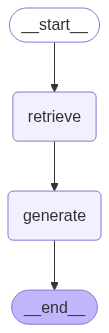

In [21]:
from IPython.display import Image, display

display(Image(rag_graph.get_graph().draw_mermaid_png()))

In [22]:
# RAG 파이프라인 테스트
question = "figure 로봇의 S1과 S2 시스템에 대해 설명해주세요. 플로우차트에서는 어떻게 표현되고 있는건가요?"
initial_state = {"question": question}

# config 설정
config = {"configurable": {"thread_id": "test_thread"}}

result=rag_graph.invoke(initial_state, config)
print(result)

INFO:httpx:HTTP Request: POST http://localhost:6333/collections/physical_ai_report_mm/points/search "HTTP/1.1 200 OK"


[{'role': 'system', 'content': '다음 검색된 문서들을 바탕으로 질문에 답변해주세요. 문서들은 이미지와 텍스트로 구성되어 있습니다.'}, {'role': 'user', 'content': "질문: figure 로봇의 S1과 S2 시스템에 대해 설명해주세요. 플로우차트에서는 어떻게 표현되고 있는건가요?\n\n검색된 문서들:\n\n문서 1:\n텍스트: \n\n문서 2:\n텍스트: - * 출처 : https://www.figure.ai/\n- ● 2025년 2월, 자사 로봇의 인식, 언어 이해, 제어 기능을 통합하여 기존 로봇 공학의 한계를 극복하기 위해 시각-언어-행동(VLA, Vision-Language-Action) 모델 '헬릭스(Helix)'를 공개(Figure.ai, 2025. 2.)\n- ∙ 기존에는 로봇에게 새로운 행동을 가르치려면 전문가의 수동 프로그래밍이나 수천 번의 시뮬레이션이 필요했으나, 헬릭스는 로봇이 카메라로 수집한 시각 정보와 자연어 명령을 결합하여 이전에 접한 적 없는 물체도 실시간으로 조작\n- ∙ 작업별 미세조정 없이 단일 신경망으로 모든 동작을 학습하는 한편, 기기 내장형 저전력 GPU에서 실행 할 수 있어 신속한 상용화를 지원\n- ∙ 시스템 2(S2)와 시스템 1(S1)이라는 2개의 시스템을 통해 휴머노이드 로봇의 상반신 전체를 고속으로 정밀하게 제어\n- ∙ S2는 초당 7~9회 속도로 작동하며, 장면과 언어를 이해하고 VLM 기반의 사전 지식을 활용해 고수준 목표에 대한 판단을 담당하고, S1은 초당 200회 속도로 작동하며 S2의 의미 표현을 정밀하고 연속적인 로봇 동작으로 실시간 실행하며 상호 보완적으로 작용\n\n## &lt;그림 3-4&gt; Figure AI 헬릭스의 시스템 2와 시스템 1 작동 방식\n\n* 출처 : Figure AI, Helix: A Vision-Language-Action Model for Generalist Humanoid Control, 2025. 2.\n\n<!-- i

INFO:httpx:HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"


{'question': 'figure 로봇의 S1과 S2 시스템에 대해 설명해주세요. 플로우차트에서는 어떻게 표현되고 있는건가요?', 'documents': [Document(metadata={'score': 0.46743363, 'image_path': './scratch\\physical_ai_report-20.png', 'source': 'voyage', 'text': ''}, page_content=''), Document(metadata={'score': 0.3806699, 'image_path': './scratch\\physical_ai_report-25.png', 'source': 'voyage', 'text': "- * 출처 : https://www.figure.ai/\n- ● 2025년 2월, 자사 로봇의 인식, 언어 이해, 제어 기능을 통합하여 기존 로봇 공학의 한계를 극복하기 위해 시각-언어-행동(VLA, Vision-Language-Action) 모델 '헬릭스(Helix)'를 공개(Figure.ai, 2025. 2.)\n- ∙ 기존에는 로봇에게 새로운 행동을 가르치려면 전문가의 수동 프로그래밍이나 수천 번의 시뮬레이션이 필요했으나, 헬릭스는 로봇이 카메라로 수집한 시각 정보와 자연어 명령을 결합하여 이전에 접한 적 없는 물체도 실시간으로 조작\n- ∙ 작업별 미세조정 없이 단일 신경망으로 모든 동작을 학습하는 한편, 기기 내장형 저전력 GPU에서 실행 할 수 있어 신속한 상용화를 지원\n- ∙ 시스템 2(S2)와 시스템 1(S1)이라는 2개의 시스템을 통해 휴머노이드 로봇의 상반신 전체를 고속으로 정밀하게 제어\n- ∙ S2는 초당 7~9회 속도로 작동하며, 장면과 언어를 이해하고 VLM 기반의 사전 지식을 활용해 고수준 목표에 대한 판단을 담당하고, S1은 초당 200회 속도로 작동하며 S2의 의미 표현을 정밀하고 연속적인 로봇 동작으로 실시간 실행하며 상호 보완적으로 작용\n\n## &lt;그림 3-4&gt; Figure AI 헬릭스

In [26]:
print(result['answer'])

Figure AI의 S1 및 S2 시스템은 휴머노이드 로봇의 제어 및 인지 기능을 통합하여 새로운 행동을 학습하는 데 초점을 맞춘 시스템입니다. 이 시스템은 다음과 같이 작동합니다.

**S1 (시스템 1):**

*   S2에서 생성된 의미 표현을 실시간으로 정밀하고 연속적인 로봇 동작으로 실행합니다.
*   초당 200회 속도로 작동하며, S2의 명령을 실행하는 역할을 합니다.
*   로봇의 움직임을 제어하고, 실제 환경에서 동작을 수행하는 데 핵심적인 역할을 합니다.

**S2 (시스템 2):**

*   장면과 언어를 이해하고 VLM (Vision-Language Model) 기반의 사전 지식을 활용하여 고수준 목표에 대한 판단을 담당합니다.
*   초당 7~9회 속도로 작동하며, S1에 명령을 전달합니다.
*   S1이 실행해야 할 동작을 결정하고, 로봇이 목표를 달성하도록 돕습니다.

**전반적인 작동 방식:**

S1과 S2는 상호 보완적으로 작동하여 로봇이 복잡한 작업을 수행할 수 있도록 합니다. S2는 고수준의 목표를 설정하고, S1은 이를 실시간으로 실행하여 로봇이 목표를 달성하도록 돕습니다.

**Figure AI의 3단계 컴퓨팅 구조:**

Figure AI는 S1 및 S2 시스템을 포함하여 로봇의 제어 및 인지 기능을 위한 3단계 컴퓨팅 구조를 사용합니다.

1.  **최상위계층 (AI 모델):** NVIDIA DGX - 로봇이 물리적 세계에 적응할 수 있도록 훈련하는 AI 모델을 운영합니다.
2.  **중간계층 (디지털 트윈):** NVIDIA OVX - 옴니버스(Omniverse)에서 Isaac Sim*을 실행하여 로봇이 실제 환경에서 실험하지 않고도 다양한 움직임과 작업을 시뮬레이션할 수 있도록 합니다.
3.  **하위 계층 (에지/실시간 컴퓨터):** NVIDIA AGX (Jetson Thor) - 로봇 내부에는 NVIDIA의 최신 Blackwell 아키텍처 기반으로 설계된 NVIDIA Jetson Thor 시스템온칩(SoC)이 